In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy import stats as scipy_stats

Loading data...
Total observations: 1971

TESTING DIFFERENT FEATURE COMBINATIONS FOR CLUSTERING

Testing: depth
Features: ['DEPTH']

  2 clusters:
    Silhouette Score:    0.5974 (higher is better)
    Davies-Bouldin:      0.5622 (lower is better)
    Calinski-Harabasz:   4010.9 (higher is better)
    Cluster sizes:       [664, 1307]

Testing: Geographic + K_PAR
Features: ['Lon_Dec', 'PAR']

  2 clusters:
    Silhouette Score:    0.6171 (higher is better)
    Davies-Bouldin:      0.6406 (lower is better)
    Calinski-Harabasz:   1828.6 (higher is better)
    Cluster sizes:       [1689, 282]

Testing: Geographic + Integrated
Features: ['Lon_Dec', 'ESTCHL_SUMMED']

  2 clusters:
    Silhouette Score:    0.4660 (higher is better)
    Davies-Bouldin:      0.8564 (lower is better)
    Calinski-Harabasz:   1414.0 (higher is better)
    Cluster sizes:       [1038, 933]

Testing: CHL
Features: ['ESTCHL_SUMMED']

  2 clusters:
    Silhouette Score:    0.8259 (higher is better)
    Davies-Bouldi

/var/folders/xn/9gqx3sxx3s32k1ttvhjc4fch0000gn/T/ipykernel_35819/3747376566.py:261: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1, 1].boxplot(data_to_plot, labels=[f'Cluster {i}' for i in range(n_clusters)],



Saved: ../results/best_clustering_visualization.png


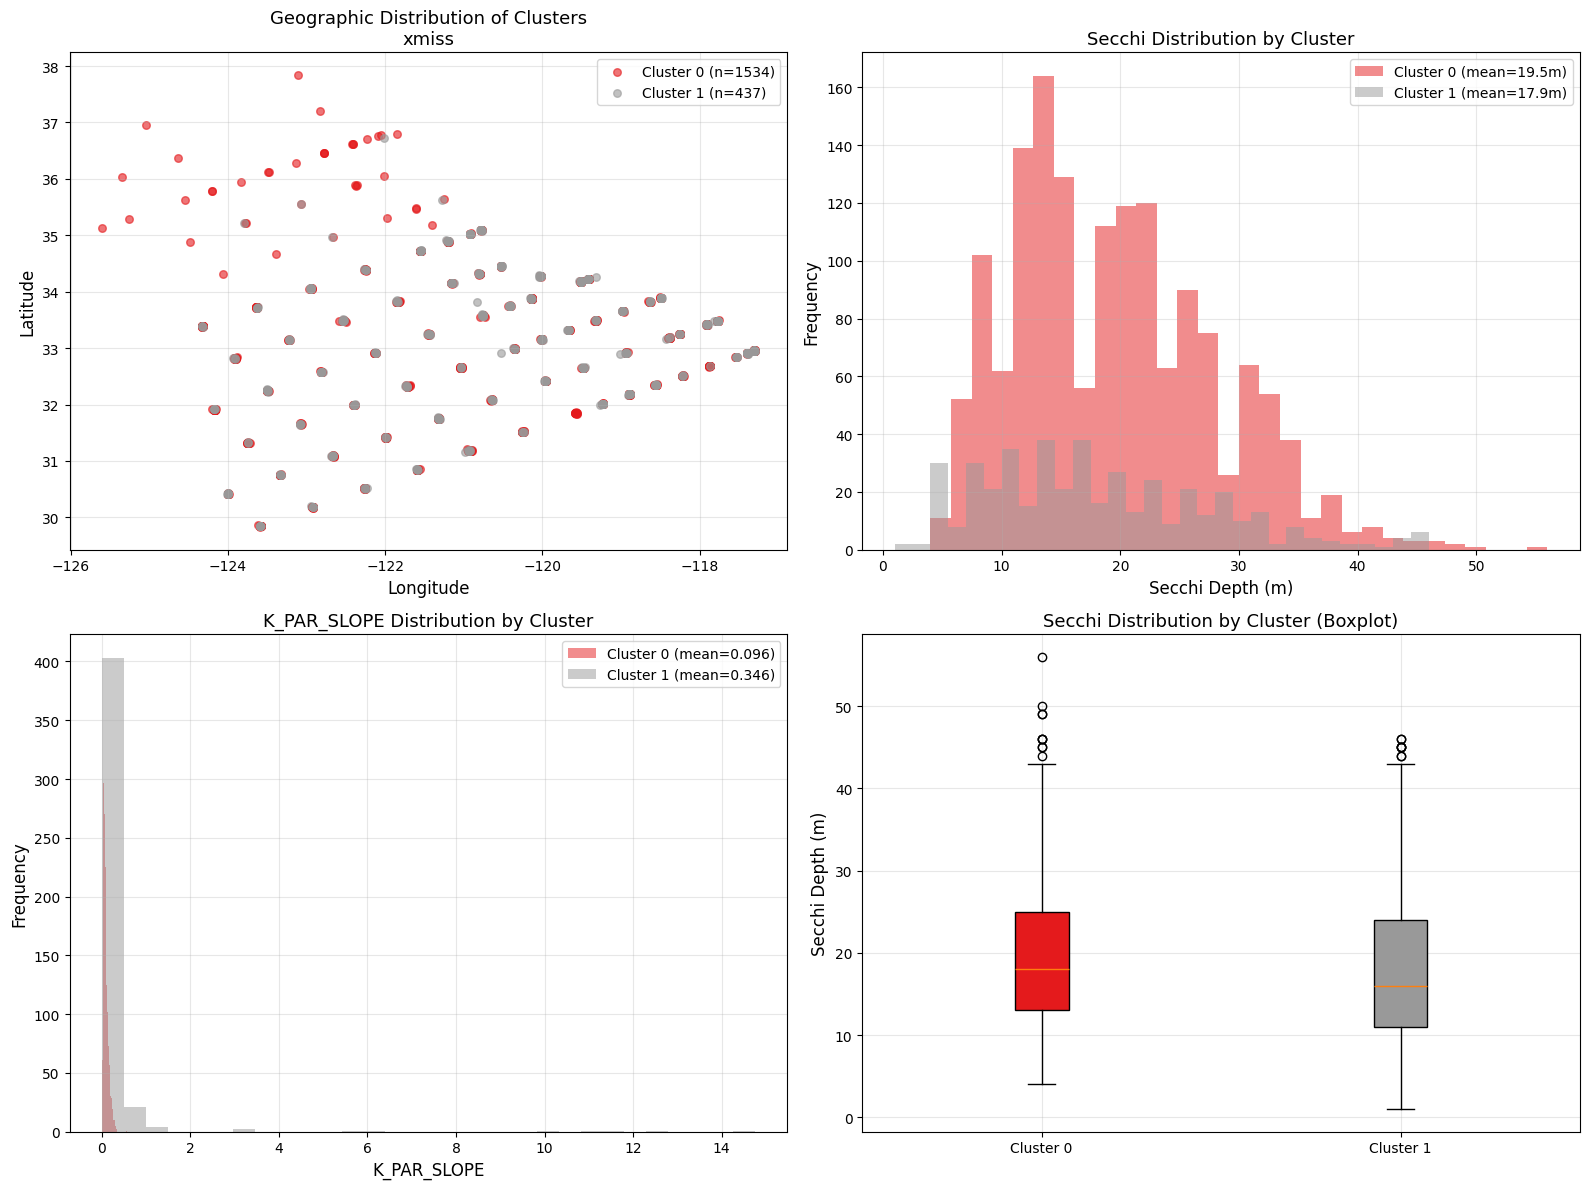


STATISTICAL VALIDATION OF CLUSTERS

T-test between clusters:
  t-statistic: 3.1850
  p-value: 1.4704e-03
  ✓ Clusters are SIGNIFICANTLY different (p < 0.05)

Other feature comparisons:
  K_PAR: ✓ p=0.0000
  XMISS_SUMMED: ✓ p=0.0000
  CHL_A_SUMMED: ✓ p=0.0000
  DEPTH: ✓ p=0.0000

4/4 features show significant differences

HIERARCHICAL CLUSTERING DENDROGRAM
Saved: ../results/dendrogram.png


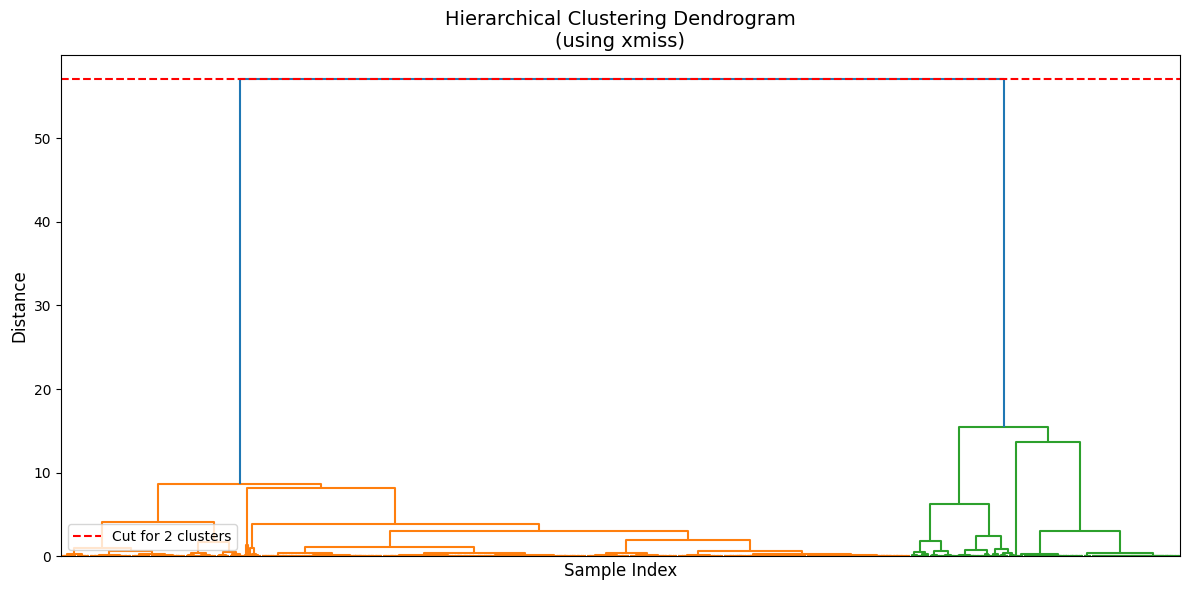


Clustered dataset saved to: ../results/data_with_clusters.csv
Cluster summary saved to: ../results/cluster_summary.csv

RECOMMENDATION

Best clustering configuration:
  Feature combination: xmiss
  Number of clusters: 2
  Silhouette score: 0.8380
  Cluster sizes: [1534, 437]

✓ STRONG clustering structure detected
  Recommendation: Build separate models for each cluster

Next steps:
  1. Review visualizations to understand cluster characteristics
  2. Train separate Random Forest models for each cluster
  3. Compare cluster-specific models vs. overall model

ANALYSIS COMPLETE!


In [3]:
print("Loading data...")
df = pd.read_parquet("../Data/Parquet/New_estchlsummed.parquet")

df = df[df['Lat_Dec'].notna() & df['Lon_Dec'].notna() & df['Secchi'].notna()].copy()

print(f"Total observations: {len(df)}")

results_dir = Path("../results")
results_dir.mkdir(exist_ok=True)

print("\n" + "="*80)
print("TESTING DIFFERENT FEATURE COMBINATIONS FOR CLUSTERING")
print("="*80)

feature_sets = {
    # 'Geographic Only': ['Lon_Dec'],
    
    # 'Geographic + Depth': ['Lat_Dec', 'Lon_Dec', 'DEPTH'],

    'depth': ['DEPTH'],
    
    'Geographic + K_PAR': ['Lon_Dec', 'PAR'],
    
    'Geographic + Integrated': ['Lon_Dec', 'ESTCHL_SUMMED'],
    
    'CHL': ['ESTCHL_SUMMED'],

    'xmiss': ['XMISS_SUMMED'],

    'xmiss + clh': ['XMISS_SUMMED', 'ESTCHL_SUMMED'],

    'dist': ['Distance'],

    # 'chla': ['CHL_A_SUMMED'], # small cluster only has 87 obs - DON'T INCLUDE

    # 'K_PAR_SLOPE': ['K_PAR_SLOPE'], # small cluster has only 7 obs - DON'T INCLUDE

    'spar and chl': ['SPAR', 'ESTCHL_SUMMED'],
    
    # 'Full Physics': ['Lon_Dec', 'PAR',
    #                  'ESTCHL_SUMMED', 'DEPTH'],
    
    'Recommended': ['Lon_Dec', 'PAR', 'ESTCHL_SUMMED']  # Your suggested combo
}

def evaluate_clustering(data, features, n_clusters_range=[2, 5], method='kmeans'):
    """
    Evaluate clustering with different numbers of clusters
    Returns metrics and best configuration
    """
    # Prepare data
    X = data[features].copy()
    
    # Remove rows with any missing values in selected features
    X = X.dropna()
    
    if len(X) < 50:
        print(f"  ⚠ Not enough data after removing NaNs: {len(X)} rows")
        return None
    
    # Standardize features (important for clustering!)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    results = []
    
    for n_clusters in n_clusters_range:
        # Perform clustering
        if method == 'kmeans':
            clusterer = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        else:  # hierarchical
            clusterer = AgglomerativeClustering(n_clusters=n_clusters)
        
        labels = clusterer.fit_predict(X_scaled)

        # Calculate metrics (higher silhouette = better, lower davies_bouldin = better)
        silhouette = silhouette_score(X_scaled, labels)
        davies_bouldin = davies_bouldin_score(X_scaled, labels)
        calinski = calinski_harabasz_score(X_scaled, labels)
        
        # Calculate cluster sizes
        cluster_sizes = pd.Series(labels).value_counts().sort_index()
        
        results.append({
            'n_clusters': n_clusters,
            'silhouette': silhouette,
            'davies_bouldin': davies_bouldin,
            'calinski_harabasz': calinski,
            'cluster_sizes': cluster_sizes.tolist(),
            'labels': labels,
            'scaler': scaler,
            'data_indices': X.index
        })

        return results
    

# ============================================================================
# EVALUATE ALL FEATURE SETS
# ============================================================================

all_results = {}

for set_name, features in feature_sets.items():
    print(f"\n{'='*60}")
    print(f"Testing: {set_name}")
    print(f"Features: {features}")
    print(f"{'='*60}")
    
    # Check if all features exist
    missing_features = [f for f in features if f not in df.columns]
    if missing_features:
        print(f"  ⚠ Skipping - missing features: {missing_features}")
        continue

    # Test with KMeans
    results_kmeans = evaluate_clustering(df, features, n_clusters_range=[2, 3], method='kmeans')
    
    if results_kmeans:
        all_results[set_name] = {
            'features': features,
            'kmeans': results_kmeans
        }

        # Print results for each n_clusters
        for res in results_kmeans:
            print(f"\n  {res['n_clusters']} clusters:")
            print(f"    Silhouette Score:    {res['silhouette']:.4f} (higher is better)")
            print(f"    Davies-Bouldin:      {res['davies_bouldin']:.4f} (lower is better)")
            print(f"    Calinski-Harabasz:   {res['calinski_harabasz']:.1f} (higher is better)")
            print(f"    Cluster sizes:       {res['cluster_sizes']}")

# ============================================================================
# FIND BEST CLUSTERING
# ============================================================================

print("\n" + "="*80)
print("BEST CLUSTERING CONFIGURATIONS")
print("="*80)

# Rank by silhouette score (most interpretable metric)
best_configs = []

for set_name, data in all_results.items():
    for res in data['kmeans']:
        best_configs.append({
            'Feature Set': set_name,
            'N Clusters': res['n_clusters'],
            'Silhouette': res['silhouette'],
            'Davies-Bouldin': res['davies_bouldin'],
            'Calinski-Harabasz': res['calinski_harabasz'],
            'Cluster Sizes': str(res['cluster_sizes']),
            '_data': res  # Store for later use
        })

best_configs_df = pd.DataFrame(best_configs)
best_configs_df = best_configs_df.sort_values(by='Silhouette', ascending=False)

print("\nTop 5 configurations by Silhouette Score:")
print(best_configs_df.head(10)[['Feature Set', 'N Clusters', 'Silhouette', 
                                 'Davies-Bouldin', 'Cluster Sizes']].to_string(index=False))

# Save rankings
best_configs_df.to_csv(results_dir / "clustering_comparison.csv", index=False)

# ============================================================================
# VISUALIZE BEST CLUSTERING
# ============================================================================

print("\n" + "="*80)
print("VISUALIZING BEST CLUSTERING")
print("="*80)

# Use the best configuration
best_config = best_configs_df.iloc[0]
best_result = best_config['_data']
best_features = all_results[best_config['Feature Set']]['features']

print(f"\nBest configuration:")
print(f"  Feature Set: {best_config['Feature Set']}")
print(f"  Features: {best_features}")
print(f"  Number of Clusters: {best_config['N Clusters']}")
print(f"  Silhouette Score: {best_config['Silhouette']:.4f}")

# Add cluster labels to dataframe
df_clustered = df.loc[best_result['data_indices']].copy()
df_clustered['CLUSTER'] = best_result['labels']

# ============================================================================
# SPATIAL VISUALIZATION
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Geographic clusters
n_clusters = int(best_config['N Clusters'])
colors = plt.cm.Set1(np.linspace(0, 1, n_clusters))

for i in range(n_clusters):
    cluster_data = df_clustered[df_clustered['CLUSTER'] == i]
    axes[0, 0].scatter(cluster_data['Lon_Dec'], cluster_data['Lat_Dec'], 
                      c=[colors[i]], label=f'Cluster {i} (n={len(cluster_data)})',
                      alpha=0.6, s=30)

axes[0, 0].set_xlabel('Longitude', fontsize=12)
axes[0, 0].set_ylabel('Latitude', fontsize=12)
axes[0, 0].set_title(f'Geographic Distribution of Clusters\n{best_config["Feature Set"]}', fontsize=13)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Secchi distribution by cluster
for i in range(n_clusters):
    cluster_secchi = df_clustered[df_clustered['CLUSTER'] == i]['Secchi']
    axes[0, 1].hist(cluster_secchi, bins=30, alpha=0.5, 
                   label=f'Cluster {i} (mean={cluster_secchi.mean():.1f}m)',
                   color=colors[i])

axes[0, 1].set_xlabel('Secchi Depth (m)', fontsize=12)
axes[0, 1].set_ylabel('Frequency', fontsize=12)
axes[0, 1].set_title('Secchi Distribution by Cluster', fontsize=13)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: K_PAR distribution (if available)
if 'K_PAR_SLOPE' in df_clustered.columns and df_clustered['K_PAR_SLOPE'].notna().sum() > 0:
    for i in range(n_clusters):
        cluster_kpar = df_clustered[df_clustered['CLUSTER'] == i]['K_PAR_SLOPE'].dropna()
        if len(cluster_kpar) > 0:
            axes[1, 0].hist(cluster_kpar, bins=30, alpha=0.5,
                           label=f'Cluster {i} (mean={cluster_kpar.mean():.3f})',
                           color=colors[i])
    
    axes[1, 0].set_xlabel('K_PAR_SLOPE', fontsize=12)
    axes[1, 0].set_ylabel('Frequency', fontsize=12)
    axes[1, 0].set_title('K_PAR_SLOPE Distribution by Cluster', fontsize=13)
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Cluster characteristics boxplots
cluster_means = []
for i in range(n_clusters):
    cluster_data = df_clustered[df_clustered['CLUSTER'] == i]
    cluster_means.append({
        'Cluster': i,
        'Secchi': cluster_data['Secchi'].mean(),
        'K_PAR': cluster_data['K_PAR'].mean() if 'K_PAR' in cluster_data else np.nan,
        'Depth': cluster_data['DEPTH'].mean(),
        'Lat': cluster_data['Lat_Dec'].mean(),
        'Lon': cluster_data['Lon_Dec'].mean(),
        'N': len(cluster_data)
    })

cluster_summary = pd.DataFrame(cluster_means)
print(f"\nCluster Summary:")
print(cluster_summary.to_string(index=False))


# Boxplot
data_to_plot = [df_clustered[df_clustered['CLUSTER'] == i]['Secchi'].dropna() 
                for i in range(n_clusters)]
bp = axes[1, 1].boxplot(data_to_plot, labels=[f'Cluster {i}' for i in range(n_clusters)],
                        patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)

axes[1, 1].set_ylabel('Secchi Depth (m)', fontsize=12)
axes[1, 1].set_title('Secchi Distribution by Cluster (Boxplot)', fontsize=13)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(results_dir / "best_clustering_visualization.png", dpi=300, bbox_inches='tight')
print(f"\nSaved: {results_dir / 'best_clustering_visualization.png'}")
plt.show()

# ============================================================================
# STATISTICAL VALIDATION
# ============================================================================

print("\n" + "="*80)
print("STATISTICAL VALIDATION OF CLUSTERS")
print("="*80)

# ANOVA test for Secchi across clusters
cluster_groups = [df_clustered[df_clustered['CLUSTER'] == i]['Secchi'].dropna() 
                  for i in range(n_clusters)]

if n_clusters == 2:
    # T-test for 2 clusters
    t_stat, p_value = scipy_stats.ttest_ind(cluster_groups[0], cluster_groups[1])
    print(f"\nT-test between clusters:")
    print(f"  t-statistic: {t_stat:.4f}")
    print(f"  p-value: {p_value:.4e}")
else:
    # ANOVA for 3+ clusters
    f_stat, p_value = scipy_stats.f_oneway(*cluster_groups)
    print(f"\nANOVA test across clusters:")
    print(f"  F-statistic: {f_stat:.4f}")
    print(f"  p-value: {p_value:.4e}")

if p_value < 0.05:
    print(f"  ✓ Clusters are SIGNIFICANTLY different (p < 0.05)")
else:
    print(f"  ✗ Clusters are NOT significantly different (p >= 0.05)")

# Test other features
features_to_test = ['K_PAR', 'XMISS_SUMMED', 'CHL_A_SUMMED', 'DEPTH']
sig_features = []

print(f"\nOther feature comparisons:")
for feature in features_to_test:
    if feature in df_clustered.columns and df_clustered[feature].notna().sum() > 10:
        groups = [df_clustered[df_clustered['CLUSTER'] == i][feature].dropna() 
                 for i in range(n_clusters)]
        
        # Skip if any group is empty
        if all(len(g) > 0 for g in groups):
            if n_clusters == 2:
                t_stat, p_val = scipy_stats.ttest_ind(groups[0], groups[1])
            else:
                f_stat, p_val = scipy_stats.f_oneway(*groups)
            
            sig = '✓' if p_val < 0.05 else '✗'
            if p_val < 0.05:
                sig_features.append(feature)
            print(f"  {feature}: {sig} p={p_val:.4f}")

print(f"\n{len(sig_features)}/{len(features_to_test)} features show significant differences")


# ============================================================================
# DENDROGRAM (Hierarchical Clustering Visualization)
# ============================================================================

print("\n" + "="*80)
print("HIERARCHICAL CLUSTERING DENDROGRAM")
print("="*80)

# Use best features
X_dendro = df_clustered[best_features].copy()
scaler_dendro = StandardScaler()
X_dendro_scaled = scaler_dendro.fit_transform(X_dendro)

# Perform hierarchical clustering
linkage_matrix = linkage(X_dendro_scaled, method='ward')

# Plot dendrogram
plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, no_labels=True, color_threshold=linkage_matrix[-n_clusters+1, 2])
plt.title(f'Hierarchical Clustering Dendrogram\n(using {best_config["Feature Set"]})', fontsize=14)
plt.xlabel('Sample Index', fontsize=12)
plt.ylabel('Distance', fontsize=12)
plt.axhline(y=linkage_matrix[-n_clusters+1, 2], color='r', linestyle='--', 
           label=f'Cut for {n_clusters} clusters')
plt.legend()
plt.tight_layout()
plt.savefig(results_dir / "dendrogram.png", dpi=300, bbox_inches='tight')
print(f"Saved: {results_dir / 'dendrogram.png'}")
plt.show()

# ============================================================================
# SAVE CLUSTERED DATASET
# ============================================================================

output_path = results_dir / "data_with_clusters.csv"
df_clustered.to_csv(output_path, index=False)
print(f"\nClustered dataset saved to: {output_path}")

# Save cluster summary
cluster_summary.to_csv(results_dir / "cluster_summary.csv", index=False)
print(f"Cluster summary saved to: {results_dir / 'cluster_summary.csv'}")

# ============================================================================
# RECOMMENDATION
# ============================================================================

print("\n" + "="*80)
print("RECOMMENDATION")
print("="*80)

print(f"\nBest clustering configuration:")
print(f"  Feature combination: {best_config['Feature Set']}")
print(f"  Number of clusters: {n_clusters}")
print(f"  Silhouette score: {best_config['Silhouette']:.4f}")
print(f"  Cluster sizes: {best_config['Cluster Sizes']}")

if best_config['Silhouette'] > 0.3:
    print(f"\n✓ STRONG clustering structure detected")
    print(f"  Recommendation: Build separate models for each cluster")
elif best_config['Silhouette'] > 0.2:
    print(f"\n~ MODERATE clustering structure detected")
    print(f"  Recommendation: Test both cluster-specific and overall models")
else:
    print(f"\n✗ WEAK clustering structure detected")
    print(f"  Recommendation: Single model may be sufficient")

print(f"\nNext steps:")
print(f"  1. Review visualizations to understand cluster characteristics")
print(f"  2. Train separate Random Forest models for each cluster")
print(f"  3. Compare cluster-specific models vs. overall model")

print("\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)